In [74]:
import pandas as pd

In [75]:
df_orginal = pd.read_csv('Resume.csv')

In [351]:
df = df_orginal.copy()

In [77]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [12]:
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [13]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [352]:
df = df.drop(['ID','Resume_html'],axis = 1)

In [16]:
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [353]:
count = df['Category'].value_counts()
label = df['Category'].unique()

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

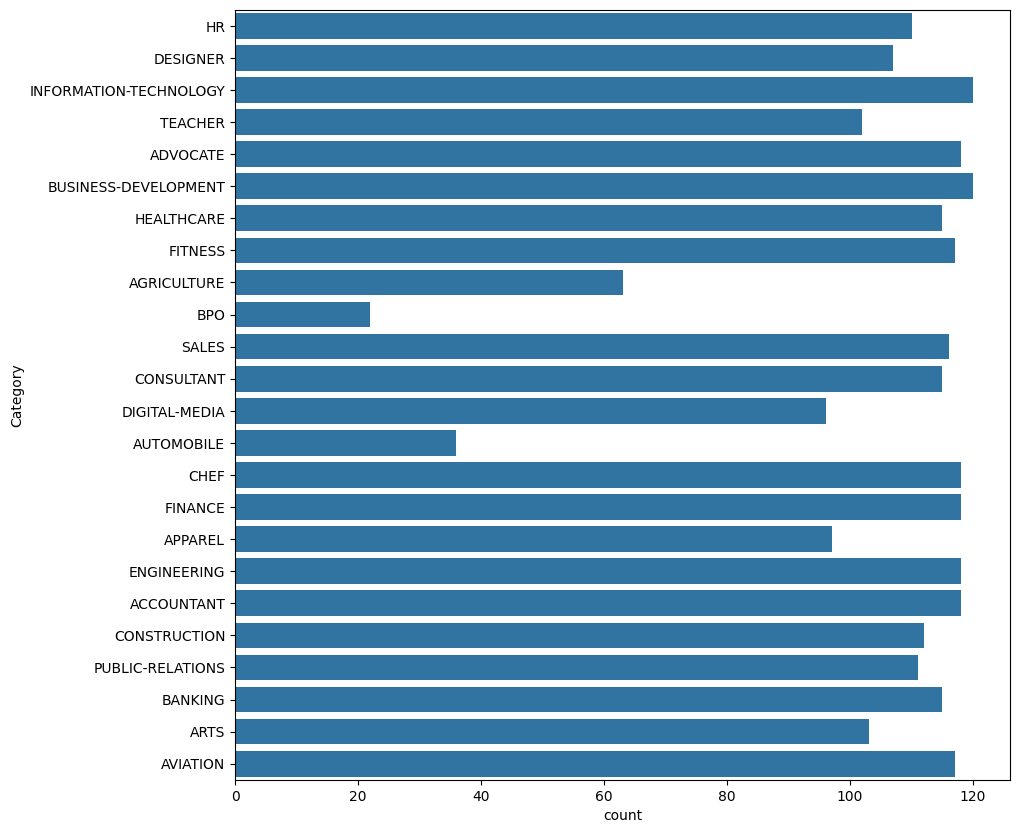

In [52]:
plt.figure(figsize = (10,10))
sns.countplot(df['Category'])
plt.show()           

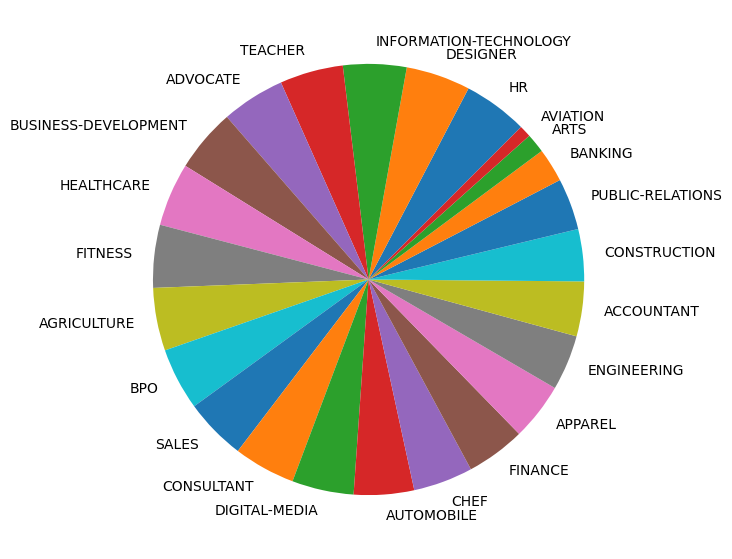

In [47]:
plt.figure(figsize=(15,7))
plt.pie(count,labels = label,startangle = 45)
plt.show()

In [60]:
df.isnull().sum()

Resume_str    0
Category      0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [354]:
df = df.drop_duplicates()

# Encoding Category

In [355]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [356]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

print(le.classes_)

['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [357]:
import joblib
joblib.dump(le,"label_encoder.pkl")

['label_encoder.pkl']

In [288]:
df['Category']

0       19
1       19
2       19
3       19
4       19
        ..
2478     6
2479     6
2480     6
2481     6
2482     6
Name: Category, Length: 2482, dtype: int64

# Text Cleaning

In [358]:
#Lower Case
def lower_case(text):
    return text.lower()

In [359]:
df['Resume_str'] = df['Resume_str'].apply(lower_case)

In [179]:
# Removing other characters
import re

In [242]:
def removing_characters(text):
    clean = re.sub('http\S+\s',' ',text)
    clean = re.sub(r'\S+@\S+', ' ', clean)
    clean = re.sub(r'\b\d{10,}\b', ' ', clean) 
    clean = re.sub(r'\d+', ' ', clean) 
    clean = re.sub(r'[^\x00-\x7f]',' ',clean)
    return clean

In [360]:
df['Resume_str'] = df['Resume_str'].apply(removing_characters)

In [208]:
df['Resume_str'][0]

"         hr administrator/marketing associate\n\nhr administrator       summary     dedicated customer service manager with  + years of experience in hospitality and customer service management.   respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         highlights         focused on customer satisfaction  team management  marketing savvy  conflict resolution techniques     training and development  skilled multi-tasker  client relations specialist           accomplishments      missouri dot supervisor training certification  certified by ihg in customer loyalty and marketing by segment   hilton worldwide general manager training certification  accomplished trainer for cross server hospitality systems such as    hilton onq  ,   micros    opera pms   , fidelio    opera    reservation system (ors) ,   holidex    completed courses and seminars in customer service, sales strategies, inventory control, loss pre

In [221]:
#Removing Punctaution
new = re.compile(r"[-$<>*?#:';+&/,.\@\(\)!]")

In [222]:
def clean_punctauation(text):
    text = new.sub(" ",text)
    text = text.replace('－', ' ')
    return text

In [361]:
df['Resume_str'] = df['Resume_str'].apply(clean_punctauation)

In [245]:
df['Resume_str'][0]

'         hr administrator marketing associate\n\nhr administrator       summary     dedicated customer service manager with    years of experience in hospitality and customer service management    respected builder and leader of customer focused teams  strives to instill a shared  enthusiastic commitment to customer service          highlights         focused on customer satisfaction  team management  marketing savvy  conflict resolution techniques     training and development  skilled multi tasker  client relations specialist           accomplishments      missouri dot supervisor training certification  certified by ihg in customer loyalty and marketing by segment   hilton worldwide general manager training certification  accomplished trainer for cross server hospitality systems such as    hilton onq      micros    opera pms     fidelio    opera    reservation system  ors      holidex    completed courses and seminars in customer service  sales strategies  inventory control  loss pre

In [363]:
#handling spaces and new lines
def new_line(text):
    if not isinstance(text, str):
        return text

    text = re.sub(r'\s+', ' ', text)
    text = text.replace('\xa0', ' ')
    return text

    
df['Resume_str'] = df['Resume_str'].apply(new_line)


In [364]:
df['Resume_str'][0]

' hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr administrator marketing 

In [249]:
import nltk
from nltk.tokenize import word_tokenize

In [220]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [365]:
def text_token(text):
    text = word_tokenize(text)
    return text

In [366]:
df['Resume_str'] = df['Resume_str'].apply(text_token)

In [229]:
df['Resume_str'][0]

['hr',
 'administrator',
 'marketing',
 'associate',
 'hr',
 'administrator',
 'summary',
 'dedicated',
 'customer',
 'service',
 'manager',
 'with',
 'years',
 'of',
 'experience',
 'in',
 'hospitality',
 'and',
 'customer',
 'service',
 'management',
 'respected',
 'builder',
 'and',
 'leader',
 'of',
 'customer',
 'focused',
 'teams',
 'strives',
 'to',
 'instill',
 'a',
 'shared',
 'enthusiastic',
 'commitment',
 'to',
 'customer',
 'service',
 'highlights',
 'focused',
 'on',
 'customer',
 'satisfaction',
 'team',
 'management',
 'marketing',
 'savvy',
 'conflict',
 'resolution',
 'techniques',
 'training',
 'and',
 'development',
 'skilled',
 'multi',
 'tasker',
 'client',
 'relations',
 'specialist',
 'accomplishments',
 'missouri',
 'dot',
 'supervisor',
 'training',
 'certification',
 'certified',
 'by',
 'ihg',
 'in',
 'customer',
 'loyalty',
 'and',
 'marketing',
 'by',
 'segment',
 'hilton',
 'worldwide',
 'general',
 'manager',
 'training',
 'certification',
 'accomplished

In [ ]:
# Alpha flittering

In [367]:
def remove_short_words(text):
    return [word for word in text if word.isalpha() and len(word) > 2]

df['Resume_str'] = df['Resume_str'].apply(remove_short_words)

In [368]:
#Stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

In [369]:
df['Resume_str'] = df['Resume_str'].apply(remove_stopwords)

In [370]:
df['Resume_str'][0]

['administrator',
 'marketing',
 'associate',
 'administrator',
 'summary',
 'dedicated',
 'customer',
 'service',
 'manager',
 'years',
 'experience',
 'hospitality',
 'customer',
 'service',
 'management',
 'respected',
 'builder',
 'leader',
 'customer',
 'focused',
 'teams',
 'strives',
 'instill',
 'shared',
 'enthusiastic',
 'commitment',
 'customer',
 'service',
 'highlights',
 'focused',
 'customer',
 'satisfaction',
 'team',
 'management',
 'marketing',
 'savvy',
 'conflict',
 'resolution',
 'techniques',
 'training',
 'development',
 'skilled',
 'multi',
 'tasker',
 'client',
 'relations',
 'specialist',
 'accomplishments',
 'missouri',
 'dot',
 'supervisor',
 'training',
 'certification',
 'certified',
 'ihg',
 'customer',
 'loyalty',
 'marketing',
 'segment',
 'hilton',
 'worldwide',
 'general',
 'manager',
 'training',
 'certification',
 'accomplished',
 'trainer',
 'cross',
 'server',
 'hospitality',
 'systems',
 'hilton',
 'onq',
 'micros',
 'opera',
 'pms',
 'fidelio',


In [266]:
#lemmatization

In [372]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
def lemmatization(text):
    text = [lemmatizer.lemmatize(word) for word in text] 
    return text

In [373]:
df['Resume_str'] = df['Resume_str'].apply(lemmatization)

In [374]:
df['Resume_str'][0]

['administrator',
 'marketing',
 'associate',
 'administrator',
 'summary',
 'dedicated',
 'customer',
 'service',
 'manager',
 'year',
 'experience',
 'hospitality',
 'customer',
 'service',
 'management',
 'respected',
 'builder',
 'leader',
 'customer',
 'focused',
 'team',
 'strives',
 'instill',
 'shared',
 'enthusiastic',
 'commitment',
 'customer',
 'service',
 'highlight',
 'focused',
 'customer',
 'satisfaction',
 'team',
 'management',
 'marketing',
 'savvy',
 'conflict',
 'resolution',
 'technique',
 'training',
 'development',
 'skilled',
 'multi',
 'tasker',
 'client',
 'relation',
 'specialist',
 'accomplishment',
 'missouri',
 'dot',
 'supervisor',
 'training',
 'certification',
 'certified',
 'ihg',
 'customer',
 'loyalty',
 'marketing',
 'segment',
 'hilton',
 'worldwide',
 'general',
 'manager',
 'training',
 'certification',
 'accomplished',
 'trainer',
 'cross',
 'server',
 'hospitality',
 'system',
 'hilton',
 'onq',
 'micros',
 'opera',
 'pm',
 'fidelio',
 'opera'

In [271]:
# Joining Texts

In [375]:
def join_text(text):
    text = " ".join(text)
    return text

In [376]:
df['Resume_str']= df['Resume_str'].apply(join_text)

In [275]:
df['Resume_str'][0]

'hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction team management marketing savvy conflict resolution technique training development skilled multi tasker client relation specialist accomplishment missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality system hilton onq micros opera pm fidelio opera reservation system or holidex completed course seminar customer service sale strategy inventory control loss prevention safety time management leadership performance assessment experience hr administrator marketing associate hr administrator dec current company name city state help develop policy direc

In [377]:
# Solitting
X = df['Resume_str']
y = df['Category']

In [378]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [276]:
#Vectorization

In [379]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_new = tfidf.fit_transform(X_train)
X_test_new = tfidf.transform(X_test)

In [380]:
print(X_train_new.shape)
print(X_test_new.shape)

(1985, 10000)
(497, 10000)


# Training Different Models

### KNN Classifier

In [381]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors = 3)

In [382]:
model.fit(X_train_new,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [383]:
model1 = model.predict(X_test_new)

## Multinomial NB

In [384]:
from sklearn.naive_bayes import MultinomialNB

In [385]:
modelm = MultinomialNB()
modelm.fit(X_train_new,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [386]:
model2 = modelm.predict(X_test_new)

## Logistic Regression

In [387]:
from sklearn.linear_model import LogisticRegression

In [388]:
modell = LogisticRegression(max_iter=1000)

In [389]:
modell.fit(X_train_new,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [390]:
model3 = modell.predict(X_test_new)

## SVM

In [391]:
from sklearn.svm import LinearSVC

models = LinearSVC(class_weight = 'balanced')

models.fit(X_train_new, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [392]:
model4 = models.predict(X_test_new)

# Model Evaluation

In [393]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,ConfusionMatrixDisplay,recall_score,classification_report

## Accuracy Score

In [394]:
print("KNN:",accuracy_score(y_test,model1))
print("MultinomialNB:",accuracy_score(y_test,model2))
print("LogisticRegression: ",accuracy_score(y_test,model3))
print("SVM ",accuracy_score(y_test,model4))

KNN: 0.44466800804828976
MultinomialNB: 0.5492957746478874
LogisticRegression:  0.6398390342052314
SVM  0.7243460764587525


## F1 Score

In [395]:
print("KNN:",f1_score(y_test,model1, average = 'weighted'))
print("MultinomialNB:",f1_score(y_test,model2, average = 'weighted'))
print("LogisticRegression: ",f1_score(y_test,model3,average = 'weighted'))
print("SVM ",f1_score(y_test,model4, average = 'weighted'))

KNN: 0.4515804873799266
MultinomialNB: 0.509822797989159
LogisticRegression:  0.6218508198908397
SVM  0.7180718355444872


## Precision Score

In [396]:
print("KNN:",precision_score(y_test,model1,average = 'weighted', zero_division=0))
print("MultinomialNB:",precision_score(y_test,model2,average = 'weighted', zero_division=0))
print("LogisticRegression: ",precision_score(y_test,model3,average = 'weighted', zero_division=0))
print("SVM ",precision_score(y_test,model4,average = 'weighted', zero_division=0))

KNN: 0.5608920209370367
MultinomialNB: 0.6002732261887053
LogisticRegression:  0.6518968450143737
SVM  0.7277581331584382


## Classification Report

In [397]:
print("KNN:",classification_report(y_test,model1, zero_division=0))
print("MultinomialNB:",classification_report(y_test,model2, zero_division=0))
print("LogisticRegression: ",classification_report(y_test,model3, zero_division=0))
print("SVM ",classification_report(y_test,model4, zero_division=0))

KNN:               precision    recall  f1-score   support

           0       0.45      0.83      0.59        24
           1       0.25      0.54      0.35        24
           2       0.50      0.46      0.48        13
           3       0.21      0.26      0.23        19
           4       0.35      0.43      0.38        21
           5       0.29      0.29      0.29         7
           6       0.50      0.30      0.38        23
           7       0.48      0.43      0.45        23
           8       0.12      0.25      0.17         4
           9       0.17      0.83      0.28        24
          10       0.89      0.67      0.76        24
          11       0.81      0.59      0.68        22
          12       0.00      0.00      0.00        23
          13       0.80      0.38      0.52        21
          14       0.83      0.26      0.40        19
          15       0.71      0.50      0.59        24
          16       1.00      0.17      0.29        24
          17       0.8

## confusion matrix display

In [399]:
def plot_confusion_matrix(y_test,prediction,model_name):
    ConfusionMatrixDisplay.from_predictions(
        y_test, prediction)
    plt.title(f"{model_name}Confusion Matrix")
    plt.show()

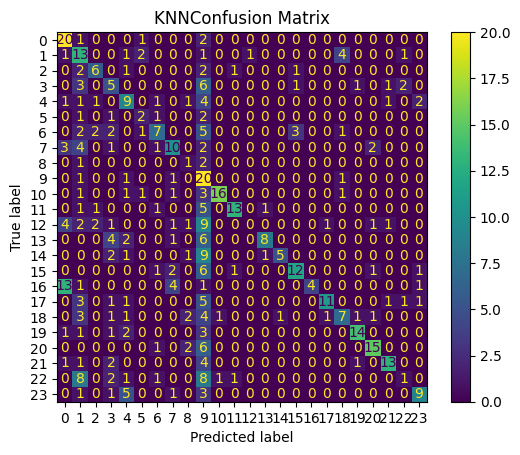

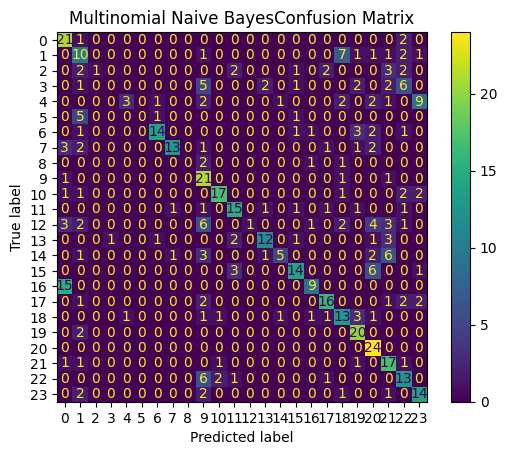

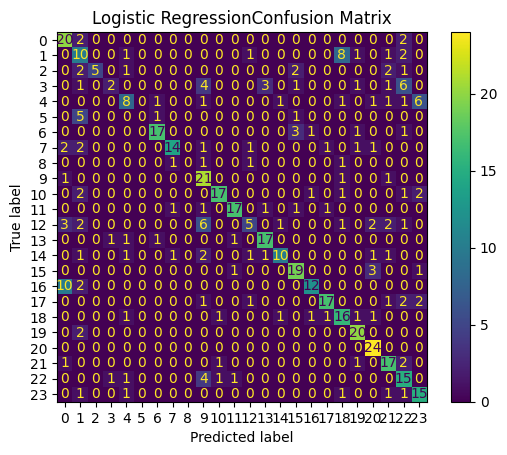

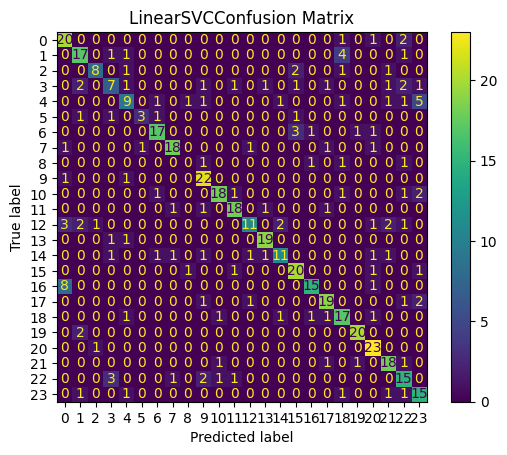

In [400]:
plot_confusion_matrix(y_test, model1, "KNN")

plot_confusion_matrix(y_test, model2, "Multinomial Naive Bayes")

plot_confusion_matrix(y_test, model3, "Logistic Regression")

plot_confusion_matrix(y_test, model4, "LinearSVC")

## Recall Score

In [401]:
print("KNN:",recall_score(y_test,model1, average = 'weighted'))
print("MultinomialNB:",recall_score(y_test,model2, average = 'weighted'))
print("LogisticRegression: ",recall_score(y_test,model3,average = 'weighted'))
print("SVM ",recall_score(y_test,model4, average = 'weighted'))

KNN: 0.44466800804828976
MultinomialNB: 0.5492957746478874
LogisticRegression:  0.6398390342052314
SVM  0.7243460764587525


## Model Comparison

| Model | Accuracy | F1 Score | Precision | Recall |
|---|---|---|---|---|
| KNN | 0.4447 | 0.4516 | 0.5609 | 0.4447 |
| Multinomial Naive Bayes | 0.5493 | 0.5098 | 0.6003 | 0.5493 |
| Logistic Regression | 0.6398 | 0.6219 | 0.6519 | 0.6398 |
| LinearSVC | 0.7243 | 0.7181 | 0.7278 | 0.7243 |


# Best Model

In [402]:
best_model = LinearSVC(class_weight='balanced')

X_all = tfidf.fit_transform(X)

best_model.fit(X_all, y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [403]:
joblib.dump(best_model, "resume_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

# Predicting Manually

In [421]:
sample_resume = X_test.iloc[0]

actual_category = le.inverse_transform([y_test.iloc[0]])[0]

resume_vector = tfidf.transform([sample_resume])

prediction = best_model.predict(resume_vector)[0]

predicted_category = le.inverse_transform([prediction])[0]

print("Actual:", actual_category)
print("Predicted:", predicted_category)

Actual: DIGITAL-MEDIA
Predicted: DIGITAL-MEDIA


## Conclusion

This project demonstrates an end-to-end NLP pipeline for resume classification using TF-IDF and machine learning models. LinearSVC was selected as the final model based on evaluation results.